In [38]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt


In [30]:
df = pd.read_csv("emotions.csv",sep=";",names=["text", "emotions"])
df["original_text"] = df["text"]
print("First 10 Rows:")
print(df.head(10))

print("\nShape of Dataset:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

First 10 Rows:
                                                text  emotions  \
0                                         text,label       NaN   
1    i just feel really helpless and heavy hearted,4       NaN   
2  ive enjoyed being able to slouch about relax a...       NaN   
3  i gave up my internship with the dmrg and am f...       NaN   
4                       i dont know i feel so lost,0       NaN   
5  i am a kindergarten teacher and i am thoroughl...       NaN   
6       i was beginning to feel quite disheartened,0       NaN   
7  i would think that whomever would be lucky eno...       NaN   
8  i fear that they won t ever feel that deliciou...       NaN   
9  im forever taking some time out to have a lie ...       NaN   

                                       original_text  
0                                         text,label  
1    i just feel really helpless and heavy hearted,4  
2  ive enjoyed being able to slouch about relax a...  
3  i gave up my internship with the dm

In [31]:
print("Unique Emotion Labels:")
print(df["emotions"].unique())

label_encoder = LabelEncoder()

df["emotion_encoded"] = label_encoder.fit_transform(df["emotions"])

emotion_mapping = dict(
    zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))
)

print("\nEmotion Label Mapping:")
print(emotion_mapping)

print("\nFirst 10 Rows:")
print(df.head(10))

Unique Emotion Labels:
[nan]

Emotion Label Mapping:
{np.float64(nan): np.int64(0)}

First 10 Rows:
                                                text  emotions  \
0                                         text,label       NaN   
1    i just feel really helpless and heavy hearted,4       NaN   
2  ive enjoyed being able to slouch about relax a...       NaN   
3  i gave up my internship with the dmrg and am f...       NaN   
4                       i dont know i feel so lost,0       NaN   
5  i am a kindergarten teacher and i am thoroughl...       NaN   
6       i was beginning to feel quite disheartened,0       NaN   
7  i would think that whomever would be lucky eno...       NaN   
8  i fear that they won t ever feel that deliciou...       NaN   
9  im forever taking some time out to have a lie ...       NaN   

                                       original_text  emotion_encoded  
0                                         text,label                0  
1    i just feel really helpl

In [32]:
print("Before Lowercasing:")
print(df["text"].head(5))

df["text"] = df["text"].str.lower()

print("\nAfter Lowercasing:")
print(df["text"].head(5))

Before Lowercasing:
0                                           text,label
1      i just feel really helpless and heavy hearted,4
2    ive enjoyed being able to slouch about relax a...
3    i gave up my internship with the dmrg and am f...
4                         i dont know i feel so lost,0
Name: text, dtype: object

After Lowercasing:
0                                           text,label
1      i just feel really helpless and heavy hearted,4
2    ive enjoyed being able to slouch about relax a...
3    i gave up my internship with the dmrg and am f...
4                         i dont know i feel so lost,0
Name: text, dtype: object


Lowercasing is important because a word, whether in capital or small holds the same meaning, humans understand this but for computer, it thinks both are different words.Therefore, lowercasing is important.

In [33]:
print("Before Removing Punctuation:")
print(df["text"].head(5))

def remove_punctuation(text):
    translator = str.maketrans("", "", string.punctuation)
    return text.translate(translator)

df["text"] = df["text"].apply(remove_punctuation)

print("\nAfter Removing Punctuation:")
print(df["text"].head(5))

Before Removing Punctuation:
0                                           text,label
1      i just feel really helpless and heavy hearted,4
2    ive enjoyed being able to slouch about relax a...
3    i gave up my internship with the dmrg and am f...
4                         i dont know i feel so lost,0
Name: text, dtype: object

After Removing Punctuation:
0                                            textlabel
1       i just feel really helpless and heavy hearted4
2    ive enjoyed being able to slouch about relax a...
3    i gave up my internship with the dmrg and am f...
4                          i dont know i feel so lost0
Name: text, dtype: object


In [34]:
print("Before Removing Numbers:")
print(df["text"].head(5))

def remove_numbers(text):
    translator = str.maketrans("", "", string.digits)
    return text.translate(translator)

df["text"] = df["text"].apply(remove_numbers)

print("\nAfter Removing Numbers:")
print(df["text"].head(5))

Before Removing Numbers:
0                                            textlabel
1       i just feel really helpless and heavy hearted4
2    ive enjoyed being able to slouch about relax a...
3    i gave up my internship with the dmrg and am f...
4                          i dont know i feel so lost0
Name: text, dtype: object

After Removing Numbers:
0                                            textlabel
1        i just feel really helpless and heavy hearted
2    ive enjoyed being able to slouch about relax a...
3    i gave up my internship with the dmrg and am f...
4                           i dont know i feel so lost
Name: text, dtype: object


In [35]:
print("Before Removing Emojis & Special Characters:")
print(df["text"].head(5))

def remove_emojis(text):
    return text.encode("ascii", "ignore").decode("ascii")

df["text"] = df["text"].apply(remove_emojis)
print("\nAfter Removing Emojis & Special Characters:")
print(df["text"].head(5))

Before Removing Emojis & Special Characters:
0                                            textlabel
1        i just feel really helpless and heavy hearted
2    ive enjoyed being able to slouch about relax a...
3    i gave up my internship with the dmrg and am f...
4                           i dont know i feel so lost
Name: text, dtype: object

After Removing Emojis & Special Characters:
0                                            textlabel
1        i just feel really helpless and heavy hearted
2    ive enjoyed being able to slouch about relax a...
3    i gave up my internship with the dmrg and am f...
4                           i dont know i feel so lost
Name: text, dtype: object


In [36]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))
print("Before Removing Stopwords:")
print(df["text"].head(5))

def remove_stopwords(text):
    words = word_tokenize(text)
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return " ".join(filtered_words)

df["text"] = df["text"].apply(remove_stopwords)

print("\nAfter Removing Stopwords:")
print(df["text"].head(5))

Before Removing Stopwords:
0                                            textlabel
1        i just feel really helpless and heavy hearted
2    ive enjoyed being able to slouch about relax a...
3    i gave up my internship with the dmrg and am f...
4                           i dont know i feel so lost
Name: text, dtype: object


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



After Removing Stopwords:
0                                            textlabel
1                   feel really helpless heavy hearted
2    ive enjoyed able slouch relax unwind frankly n...
3              gave internship dmrg feeling distraught
4                                  dont know feel lost
Name: text, dtype: object


In [37]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    translator = str.maketrans("", "", string.punctuation)
    text = text.translate(translator)

    translator = str.maketrans("", "", string.digits)
    text = text.translate(translator)

    text = text.encode("ascii", "ignore").decode("ascii")

    words = word_tokenize(text)
    words = [word for word in words if word.lower() not in stop_words]

    return " ".join(words)

df["cleaned_text"] = df["original_text"].apply(clean_text)

print(df[["original_text", "cleaned_text"]].head(10))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                       original_text  \
0                                         text,label   
1    i just feel really helpless and heavy hearted,4   
2  ive enjoyed being able to slouch about relax a...   
3  i gave up my internship with the dmrg and am f...   
4                       i dont know i feel so lost,0   
5  i am a kindergarten teacher and i am thoroughl...   
6       i was beginning to feel quite disheartened,0   
7  i would think that whomever would be lucky eno...   
8  i fear that they won t ever feel that deliciou...   
9  im forever taking some time out to have a lie ...   

                                        cleaned_text  
0                                          textlabel  
1                 feel really helpless heavy hearted  
2  ive enjoyed able slouch relax unwind frankly n...  
3            gave internship dmrg feeling distraught  
4                                dont know feel lost  
5  kindergarten teacher thoroughly weary job take... 

                                        cleaned_text  text_length
0                                          textlabel            1
1                 feel really helpless heavy hearted            5
2  ive enjoyed able slouch relax unwind frankly n...           24
3            gave internship dmrg feeling distraught            5
4                                dont know feel lost            4
5  kindergarten teacher thoroughly weary job take...           17
6                  beginning feel quite disheartened            4
7  would think whomever would lucky enough stay s...           14
8  fear ever feel delicious excitement christmas ...           10
9              im forever taking time lie feel weird            7


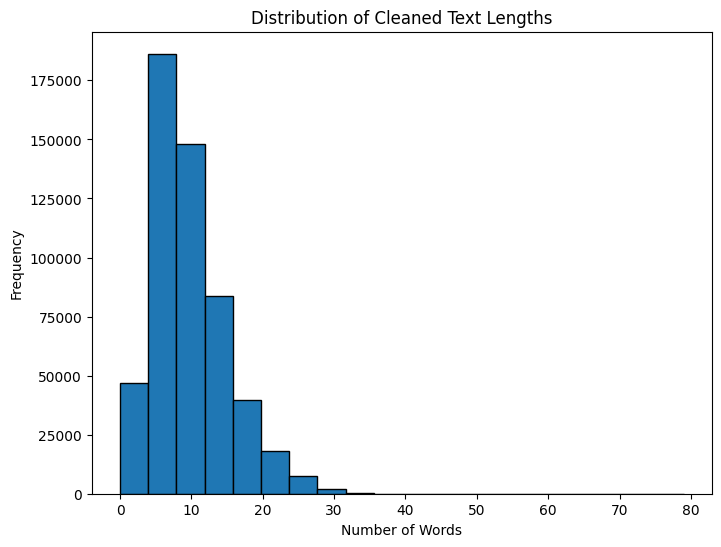

Average Text Length: 9.356542587745814
Minimum Text Length: 0
Maximum Text Length: 79


In [39]:
df["text_length"] = df["cleaned_text"].apply(lambda x: len(x.split()))

print(df[["cleaned_text", "text_length"]].head(10))

plt.figure(figsize=(8,6))

plt.hist(
    df["text_length"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Cleaned Text Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

print("Average Text Length:", df["text_length"].mean())
print("Minimum Text Length:", df["text_length"].min())
print("Maximum Text Length:", df["text_length"].max())

In [40]:
df = pd.read_csv(
    "emotions.csv",
    sep=";",
    names=["text", "emotions"]
)

label_encoder = LabelEncoder()

df["emotion_encoded"] = label_encoder.fit_transform(df["emotions"])

stop_words = set(stopwords.words("english"))

def clean_text(text):


    text = text.lower()

    translator = str.maketrans("", "", string.punctuation)
    text = text.translate(translator)
    translator = str.maketrans("", "", string.digits)
    text = text.translate(translator)

    text = text.encode("ascii", "ignore").decode("ascii")

    words = word_tokenize(text)
    words = [word for word in words if word.lower() not in stop_words]

    return " ".join(words)

df["cleaned_text"] = df["text"].apply(clean_text)

df.to_csv("cleaned_emotions.csv", index=False)

print("Dataset saved successfully as cleaned_emotions.csv")

print("\nEmotion Counts:")
print(df["emotions"].value_counts())

Dataset saved successfully as cleaned_emotions.csv

Emotion Counts:
Series([], Name: count, dtype: int64)
